This submission introduces an interactive, visualization-driven framework for understanding digital circuits using open-source tools.

Rather than focusing solely on numerical simulation, this work emphasizes intuitive exploration of circuit behavior through real-time interaction and visual analysis.

Key contributions include:
- Nonlinear CMOS inverter modeling using a sigmoid-based VTC
- Visualization of switching behavior, gain, and noise characteristics
- Interactive parameter control enabling dynamic exploration
- Multi-stage logic propagation and noise restoration analysis
- Time-based sequential logic simulation with metastability detection

By combining simulation with visualization, this notebook transforms circuit analysis into an intuitive and reproducible learning experience.

This work aligns with the goal of promoting accessible, educational, and open-source chip design methodologies.

Team: Matrix Neo  
Lead: Venkatesh K  
Email: Venkateshk@ieee.org

# Interactive Circuit Intelligence: Visualization-Driven CMOS Inverter and Sequential Logic Exploration
## From CMOS Inverter to Time-Based Logic Systems

---

| Field | Details |
|---|---|
| **Team Name** | Matrix Neo |
| **Team Lead** | Venkatesh K |
| **Email** | Venkateshk@ieee.org |
| **Competition** | IEEE SSCS Code-a-Chip — VLSI 2026 |
| **License** | Apache 2.0 |

---

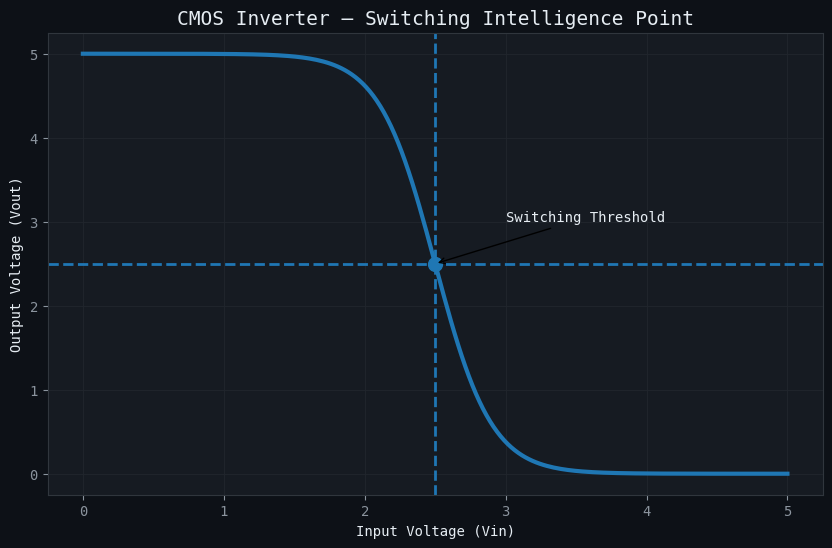

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

Vdd = 5
Vin = np.linspace(0, 5, 200)

def inverter(vin):
    return Vdd / (1 + np.exp(5*(vin - Vdd/2)))

Vout = inverter(Vin)

VM = Vdd/2

plt.figure(figsize=(10,6))
plt.plot(Vin, Vout, linewidth=3)

plt.axvline(VM, linestyle='--')
plt.axhline(VM, linestyle='--')

plt.scatter([VM], [inverter(VM)], s=100)

plt.title("CMOS Inverter — Switching Intelligence Point", fontsize=14)
plt.xlabel("Input Voltage (Vin)")
plt.ylabel("Output Voltage (Vout)")
plt.grid()

plt.annotate("Switching Threshold",
             xy=(VM, inverter(VM)),
             xytext=(VM+0.5, inverter(VM)+0.5),
             arrowprops=dict(arrowstyle="->"))

plt.show()

## 1. Objective

Build an interactive, simulation-grade notebook that:
- Models the CMOS inverter with a **nonlinear sigmoid-based transfer characteristic**
- Visualizes switching threshold, gain, and noise margins
- Simulates time-domain digital signal propagation
- Extends to a **time-based sequential logic** system (D flip-flop behavior)
- Provides real-time parameter control via `ipywidgets`

## 2. Motivation

Standard textbook inverter models use piecewise-linear approximations that mask nonlinear transitions. A differentiable sigmoid model captures:
- Continuous gain across the transition region
- Parametric sensitivity to process variation (V_th, gain steepness)
- Direct mapping to probabilistic and time-domain logic analysis

This notebook bridges device physics, logic design, and interactive engineering — suitable for educational deployment, design exploration, and open-source silicon workflows.

---

## 3. CMOS Inverter Theory (Concise)

A CMOS inverter pairs a **PMOS** (pull-up) and **NMOS** (pull-down) transistor sharing gate input $V_{in}$ and drain output $V_{out}$.

**Key regions:**

| Region | NMOS | PMOS | $V_{out}$ |
|---|---|---|---|
| $V_{in} \approx 0$ | OFF | ON (linear) | $V_{DD}$ |
| $V_{in} = V_{M}$ | Saturation | Saturation | $V_{DD}/2$ |
| $V_{in} \approx V_{DD}$ | ON (linear) | OFF | $0$ |

**Switching threshold** $V_M$ (for matched devices): $V_M \approx V_{DD}/2$

**Voltage Transfer Characteristic (VTC):** The output transitions sharply near $V_M$ with a gain $|dV_{out}/dV_{in}| \gg 1$ in the transition region.

**Noise Margins:**
$$NM_H = V_{OH} - V_{IH}, \quad NM_L = V_{IL} - V_{OL}$$

where $V_{IH}, V_{IL}$ are defined at unity-gain points on the VTC.

---

In [ ]:
# Install ipywidgets if needed (Colab)
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "ipywidgets", "-q"])

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.gridspec import GridSpec
import ipywidgets as widgets
from IPython.display import display, HTML

matplotlib.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#e6edf3',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'text.color': '#e6edf3',
    'grid.color': '#21262d',
    'grid.linewidth': 0.6,
    'lines.linewidth': 2.0,
    'font.family': 'monospace',
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})

ACCENT   = '#58a6ff'
ACCENT2  = '#f78166'
ACCENT3  = '#3fb950'
ACCENT4  = '#d2a679'
MUTED    = '#8b949e'

## 4. Nonlinear Inverter Model

The CMOS VTC is modeled as a **generalized sigmoid**:

$$V_{out}(V_{in}) = V_{DD} \cdot \frac{1}{1 + e^{\,k(V_{in} - V_M)}}$$

- $k$ — gain steepness (process-dependent; larger $k$ → sharper transition)
- $V_M$ — switching threshold ($\approx V_{DD}/2$ for matched devices)
- $V_{DD}$ — supply voltage

The instantaneous gain is:
$$A_v(V_{in}) = \frac{dV_{out}}{dV_{in}} = -\frac{k \cdot V_{DD} \cdot e^{k(V_{in}-V_M)}}{\left(1 + e^{k(V_{in}-V_M)}\right)^2}$$

Peak gain at $V_M$: $A_v^{\max} = -k \cdot V_{DD} / 4$

In [ ]:
def vtc(Vin, Vdd=1.8, Vm=None, k=10.0):
    if Vm is None:
        Vm = Vdd / 2
    return Vdd / (1.0 + np.exp(k * (Vin - Vm)))

def vtc_gain(Vin, Vdd=1.8, Vm=None, k=10.0):
    if Vm is None:
        Vm = Vdd / 2
    e = np.exp(k * (Vin - Vm))
    return -(k * Vdd * e) / (1.0 + e)**2

def unity_gain_points(Vdd=1.8, Vm=None, k=10.0, n=5000):
    if Vm is None:
        Vm = Vdd / 2
    Vin = np.linspace(0, Vdd, n)
    gain = vtc_gain(Vin, Vdd, Vm, k)
    idx = np.where(np.diff(np.sign(gain + 1.0)))[0]
    pts = []
    for i in idx:
        x0, x1 = Vin[i], Vin[i+1]
        g0, g1 = gain[i]+1, gain[i+1]+1
        xc = x0 - g0*(x1-x0)/(g1-g0)
        pts.append(xc)
    return pts

## 5. Voltage Transfer Characteristic

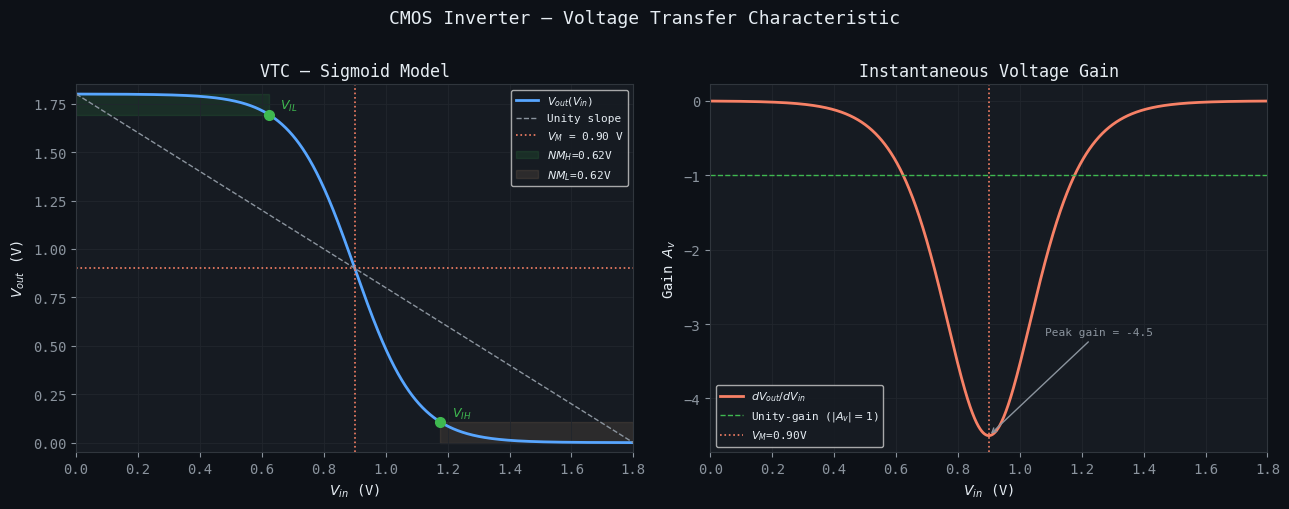

In [ ]:
def plot_vtc(Vdd=1.8, Vm=None, k=10.0):
    if Vm is None:
        Vm = Vdd / 2

    Vin  = np.linspace(0, Vdd, 2000)
    Vout = vtc(Vin, Vdd, Vm, k)
    gain = vtc_gain(Vin, Vdd, Vm, k)
    ugp  = unity_gain_points(Vdd, Vm, k)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('CMOS Inverter — Voltage Transfer Characteristic', fontsize=13, color='#e6edf3', y=1.01)

    ax1 = axes[0]
    ax1.plot(Vin, Vout, color=ACCENT, label='$V_{out}(V_{in})$')
    ax1.plot([0, Vdd], [Vdd, 0], color=MUTED, linestyle='--', linewidth=1.0, label='Unity slope')
    ax1.axvline(Vm, color=ACCENT2, linestyle=':', linewidth=1.2, label=f'$V_M$ = {Vm:.2f} V')
    ax1.axhline(Vm, color=ACCENT2, linestyle=':', linewidth=1.2)

    if len(ugp) >= 2:
        VIL, VIH = ugp[0], ugp[-1]
        VOH = vtc(VIL, Vdd, Vm, k)
        VOL = vtc(VIH, Vdd, Vm, k)
        NMH = Vdd - VIH
        NML = VIL - 0

        for xp, yp, lbl in [(VIL, VOH, '$V_{IL}$'), (VIH, VOL, '$V_{IH}$')]:
            ax1.plot(xp, yp, 'o', color=ACCENT3, markersize=7)
            ax1.annotate(lbl, (xp, yp), textcoords='offset points',
                         xytext=(8, 4), color=ACCENT3, fontsize=9)

        ax1.fill_betweenx([VOH, Vdd], 0, VIL, alpha=0.12, color=ACCENT3, label=f'$NM_H$={NMH:.2f}V')
        ax1.fill_betweenx([0, VOL], VIH, Vdd, alpha=0.12, color=ACCENT4, label=f'$NM_L$={NML:.2f}V')

    ax1.set_xlabel('$V_{in}$ (V)')
    ax1.set_ylabel('$V_{out}$ (V)')
    ax1.set_title('VTC — Sigmoid Model')
    ax1.set_xlim(0, Vdd)
    ax1.set_ylim(-0.05, Vdd + 0.05)
    ax1.legend(fontsize=8, loc='upper right')
    ax1.grid(True)

    ax2 = axes[1]
    ax2.plot(Vin, gain, color=ACCENT2, label='$dV_{out}/dV_{in}$')
    ax2.axhline(-1, color=ACCENT3, linestyle='--', linewidth=1.0, label='Unity-gain ($|A_v|=1$)')
    ax2.axvline(Vm, color=ACCENT2, linestyle=':', linewidth=1.2, label=f'$V_M$={Vm:.2f}V')
    peak_gain = -k * Vdd / 4
    ax2.annotate(f'Peak gain = {peak_gain:.1f}',
                 xy=(Vm, peak_gain), xytext=(Vm + 0.1*Vdd, peak_gain*0.7),
                 arrowprops=dict(arrowstyle='->', color=MUTED),
                 color=MUTED, fontsize=8)
    ax2.set_xlabel('$V_{in}$ (V)')
    ax2.set_ylabel('Gain $A_v$')
    ax2.set_title('Instantaneous Voltage Gain')
    ax2.set_xlim(0, Vdd)
    ax2.legend(fontsize=8)
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

plot_vtc(Vdd=1.8, k=10.0)

## 6. Interactive Parameter Control

In [ ]:
style  = {'description_width': '120px'}
layout = widgets.Layout(width='380px')

w_Vdd = widgets.FloatSlider(value=1.8, min=0.8, max=3.3, step=0.1,
                             description='Vdd (V)', style=style, layout=layout)
w_Vm  = widgets.FloatSlider(value=0.9, min=0.3, max=2.5, step=0.05,
                             description='Vm (V)',  style=style, layout=layout)
w_k   = widgets.FloatSlider(value=10.0, min=2.0, max=40.0, step=0.5,
                             description='k (gain steepness)', style=style, layout=layout)

ui = widgets.VBox([w_Vdd, w_Vm, w_k])
out = widgets.interactive_output(plot_vtc, {'Vdd': w_Vdd, 'Vm': w_Vm, 'k': w_k})
display(ui, out)

Output()

## 7. Real-Time Signal Propagation Simulation

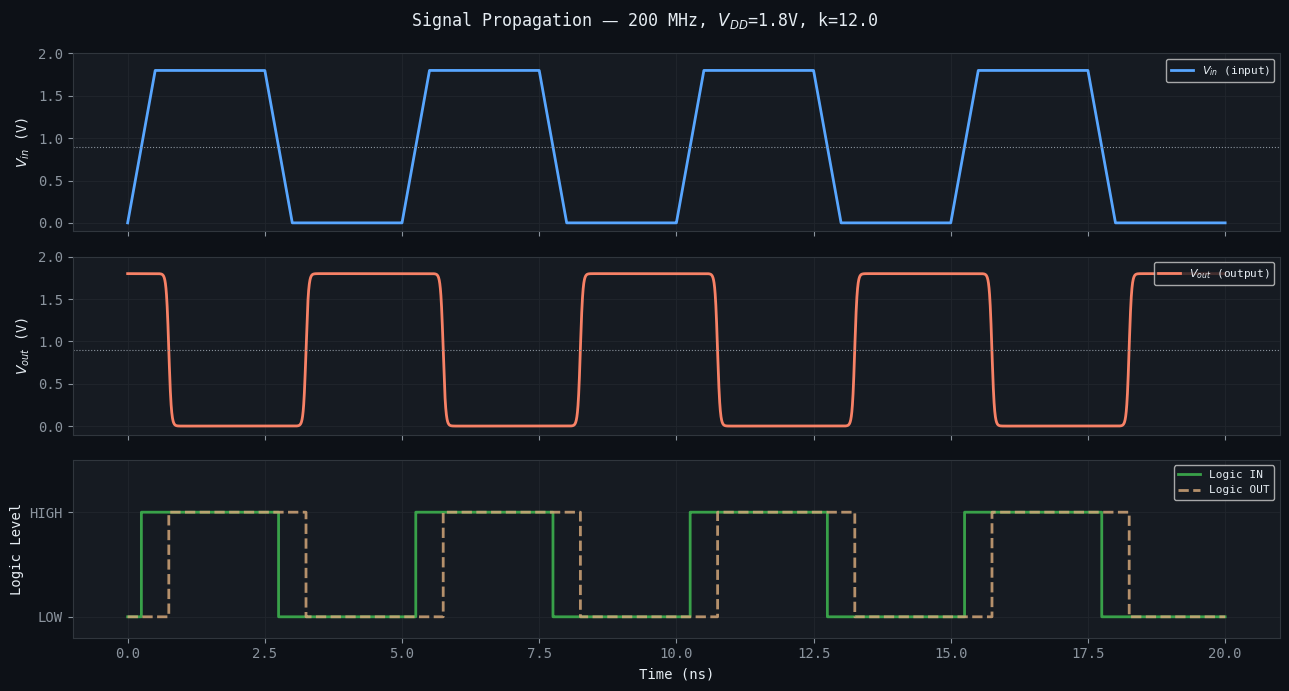

In [ ]:
def simulate_signal(Vdd=1.8, Vm=None, k=10.0, f_MHz=100, n_cycles=3,
                    rise_frac=0.1, t_delay_ns=0.5):
    if Vm is None:
        Vm = Vdd / 2

    T_ns   = 1000.0 / f_MHz
    t_total = n_cycles * T_ns
    t      = np.linspace(0, t_total, 10000)

    def trapezoid_wave(t, T, Vdd, rise_frac):
        t_mod = t % T
        half  = T / 2
        rt    = rise_frac * T
        sig   = np.zeros_like(t)
        for i, tm in enumerate(t_mod):
            if tm < rt:
                sig[i] = Vdd * tm / rt
            elif tm < half:
                sig[i] = Vdd
            elif tm < half + rt:
                sig[i] = Vdd * (1 - (tm - half) / rt)
        return sig

    Vin_wave  = trapezoid_wave(t, T_ns, Vdd, rise_frac)
    t_delayed = np.clip(t - t_delay_ns, 0, None)
    Vin_d     = trapezoid_wave(t_delayed, T_ns, Vdd, rise_frac)
    Vout_wave = vtc(Vin_d, Vdd, Vm, k)

    fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)
    fig.suptitle(f'Signal Propagation — {f_MHz} MHz, $V_{{DD}}$={Vdd}V, k={k}',
                 fontsize=12, color='#e6edf3')

    axes[0].plot(t, Vin_wave, color=ACCENT, label='$V_{in}$ (input)')
    axes[0].set_ylabel('$V_{in}$ (V)')
    axes[0].set_ylim(-0.1, Vdd + 0.2)
    axes[0].axhline(Vm, color=MUTED, linestyle=':', linewidth=0.8)
    axes[0].legend(loc='upper right', fontsize=8)
    axes[0].grid(True)

    axes[1].plot(t, Vout_wave, color=ACCENT2, label='$V_{out}$ (output)')
    axes[1].set_ylabel('$V_{out}$ (V)')
    axes[1].set_ylim(-0.1, Vdd + 0.2)
    axes[1].axhline(Vm, color=MUTED, linestyle=':', linewidth=0.8)
    axes[1].legend(loc='upper right', fontsize=8)
    axes[1].grid(True)

    digital_in  = (Vin_wave  > Vm).astype(float)
    digital_out = (Vout_wave < Vm).astype(float)
    axes[2].step(t, digital_in,  color=ACCENT3,  label='Logic IN',  where='post', alpha=0.85)
    axes[2].step(t, digital_out, color=ACCENT4,  label='Logic OUT', where='post', alpha=0.85, linestyle='--')
    axes[2].set_ylabel('Logic Level')
    axes[2].set_xlabel('Time (ns)')
    axes[2].set_ylim(-0.2, 1.5)
    axes[2].set_yticks([0, 1])
    axes[2].set_yticklabels(['LOW', 'HIGH'])
    axes[2].legend(loc='upper right', fontsize=8)
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

simulate_signal(Vdd=1.8, k=12.0, f_MHz=200, n_cycles=4)

In [ ]:
w_f   = widgets.FloatSlider(value=200.0, min=10.0, max=1000.0, step=10.0,
                             description='Freq (MHz)', style=style, layout=layout)
w_k2  = widgets.FloatSlider(value=12.0,  min=2.0,   max=40.0,  step=0.5,
                             description='k', style=style, layout=layout)
w_Vdd2= widgets.FloatSlider(value=1.8,   min=0.8,   max=3.3,   step=0.1,
                             description='Vdd (V)', style=style, layout=layout)
w_del = widgets.FloatSlider(value=0.5,   min=0.0,   max=2.0,   step=0.1,
                             description='Delay (ns)', style=style, layout=layout)

ui2  = widgets.VBox([w_Vdd2, w_k2, w_f, w_del])
out2 = widgets.interactive_output(
    simulate_signal,
    {'Vdd': w_Vdd2, 'k': w_k2, 'f_MHz': w_f, 't_delay_ns': w_del}
)
display(ui2, out2)

Output()

## 8. Logic Extension — Inverter Chains and Fan-Out

A chain of $N$ inverters propagates a signal with cumulative delay $t_p = N \cdot t_{p,inv}$.  
For even $N$: **buffer** (non-inverting); for odd $N$: **inverter**.

Fan-out degradation: each additional load capacitance $C_L$ increases $t_p$ as:
$$t_p = 0.69 \, R_{eq} \left( C_{int} + C_L \right)$$

The sigmoid model naturally captures signal **reshaping** at each stage — noisy or degraded signals recover toward $0$ or $V_{DD}$ through gain restoration.

In [ ]:
def plot_inverter_chain(Vdd=1.8, k=10.0, stages=4, noise_sigma=0.05):
    Vin_orig = np.linspace(0, Vdd, 1000)
    np.random.seed(42)
    noise    = np.random.normal(0, noise_sigma, Vin_orig.shape)
    signals  = [np.clip(Vin_orig + noise, 0, Vdd)]

    for _ in range(stages):
        signals.append(vtc(signals[-1], Vdd, Vdd/2, k))

    fig, ax = plt.subplots(figsize=(11, 5))
    colors   = plt.cm.cool(np.linspace(0.1, 0.9, stages + 1))

    for i, (sig, col) in enumerate(zip(signals, colors)):
        lbl = 'Input (noisy)' if i == 0 else f'Stage {i}'
        ax.plot(Vin_orig, sig, color=col, label=lbl, alpha=0.85,
                linewidth=1.5 if i > 0 else 1.0)

    ax.axhline(Vdd, color=MUTED, linestyle=':', linewidth=0.8)
    ax.axhline(0,   color=MUTED, linestyle=':', linewidth=0.8)
    ax.set_xlabel('$V_{in,0}$ (V)')
    ax.set_ylabel('Stage Output (V)')
    ax.set_title(f'{stages}-Stage Inverter Chain — Noise Restoration ($\\sigma$={noise_sigma}V, k={k})')
    ax.set_xlim(0, Vdd)
    ax.set_ylim(-0.05, Vdd + 0.05)
    ax.legend(fontsize=8, loc='center right')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

w_stages = widgets.IntSlider(value=4, min=1, max=8, step=1,
                              description='Stages', style=style, layout=layout)
w_noise  = widgets.FloatSlider(value=0.05, min=0.0, max=0.3, step=0.01,
                                description='Noise σ (V)', style=style, layout=layout)
w_k3     = widgets.FloatSlider(value=10.0, min=2.0, max=40.0, step=0.5,
                                description='k', style=style, layout=layout)

ui3  = widgets.VBox([w_stages, w_noise, w_k3])
out3 = widgets.interactive_output(
    plot_inverter_chain,
    {'stages': w_stages, 'noise_sigma': w_noise, 'k': w_k3}
)
display(ui3, out3)

Output()

## 9. Time-Based Sequential Logic System

### Concept

Time-based logic encodes information in **signal timing** rather than voltage levels. The basic building block is a **delay-latch**: a D flip-flop whose Q output is a delayed, inverted version of D, clocked by a reference edge.

This section simulates:
- A free-running **clock**
- Asynchronous **data input** (non-integer frequency multiple)
- **D flip-flop** behavior: Q latches D on rising clock edge
- **Inverter-delayed feedback** — propagation delay modeled via sigmoid
- Output **metastability window** detection (setup/hold violations)

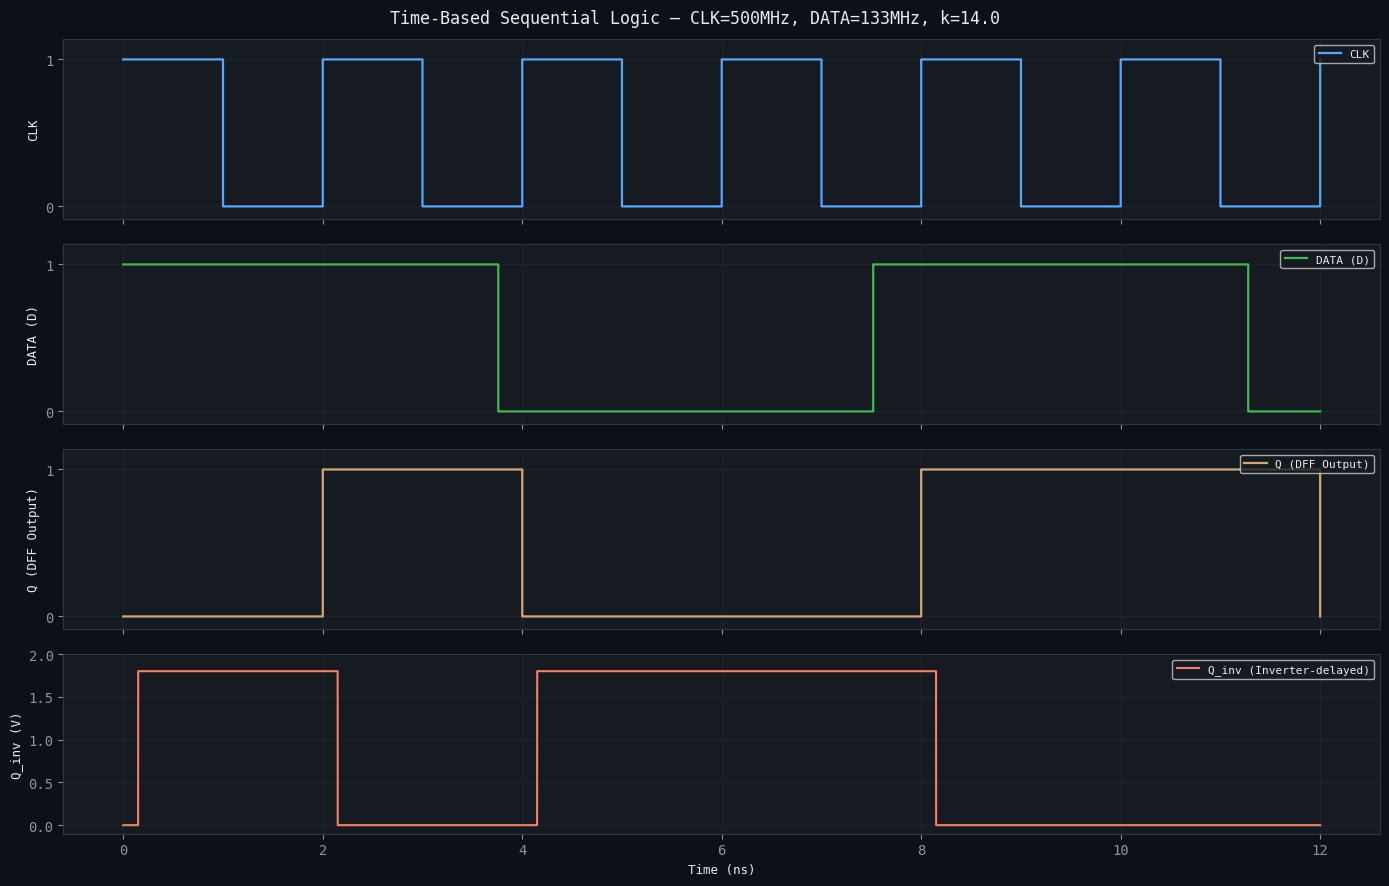


--- Simulation Summary ---
  CLK period (ns)        2.0
  DATA period (ns)       7.519
  Inv delay (ns)         0.15
  Setup violations       0


In [ ]:
def time_based_logic(Vdd=1.8, k=14.0,
                     clk_MHz=500, data_MHz=133,
                     t_setup_ns=0.2, t_hold_ns=0.1,
                     t_delay_inv_ns=0.15,
                     n_cycles=6):

    T_clk  = 1000.0 / clk_MHz
    T_data = 1000.0 / data_MHz
    t_end  = n_cycles * T_clk
    t      = np.linspace(0, t_end, 20000)
    dt     = t[1] - t[0]

    clk  = ((t % T_clk) < T_clk / 2).astype(float)
    data = ((t % T_data) < T_data / 2).astype(float)

    Vclk  = clk  * Vdd
    Vdata = data * Vdd

    # D flip-flop: latch D on rising CLK edge
    Q = np.zeros_like(t)
    q_cur = 0.0
    metastable_windows = []

    for i in range(1, len(t)):
        rising_edge = (clk[i] > 0.5) and (clk[i-1] <= 0.5)
        if rising_edge:
            t_edge = t[i]
            # Find last data transition before this edge
            data_transitions = np.where(np.diff(data[:i].astype(int)) != 0)[0]
            if len(data_transitions) > 0:
                last_trans_t = t[data_transitions[-1]]
                dt_setup = t_edge - last_trans_t
                if dt_setup < t_setup_ns:
                    metastable_windows.append(t_edge)
            q_cur = float(data[i])
        Q[i] = q_cur

    # Inverter delay on Q output
    delay_samples  = max(1, int(t_delay_inv_ns / dt))
    Vq_in          = Q * Vdd
    Vq_delayed     = np.roll(Vq_in, delay_samples)
    Vq_delayed[:delay_samples] = Vdd
    Q_inv          = vtc(Vq_delayed, Vdd, Vdd/2, k)

    fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
    fig.suptitle(
        f'Time-Based Sequential Logic — CLK={clk_MHz}MHz, DATA={data_MHz}MHz, k={k}',
        fontsize=12, color='#e6edf3'
    )

    def plot_digital(ax, t, sig, color, label, vdd=Vdd):
        ax.step(t, sig * vdd, where='post', color=color, label=label, linewidth=1.6)
        ax.set_ylim(-0.15, vdd + 0.25)
        ax.set_yticks([0, vdd])
        ax.set_yticklabels(['0', '1'])
        ax.set_ylabel(label, fontsize=9)
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True)

    plot_digital(axes[0], t, clk,  ACCENT,  'CLK')
    plot_digital(axes[1], t, data, ACCENT3, 'DATA (D)')
    plot_digital(axes[2], t, Q,    ACCENT4, 'Q (DFF Output)')

    axes[3].plot(t, Q_inv, color=ACCENT2, label='Q_inv (Inverter-delayed)', linewidth=1.5)
    axes[3].set_ylim(-0.1, Vdd + 0.2)
    axes[3].set_ylabel('Q_inv (V)', fontsize=9)
    axes[3].set_xlabel('Time (ns)', fontsize=9)
    axes[3].legend(loc='upper right', fontsize=8)
    axes[3].grid(True)

    for ax in axes:
        for tm in metastable_windows:
            ax.axvspan(tm - t_setup_ns, tm + t_hold_ns,
                       alpha=0.18, color='red', zorder=0)

    if metastable_windows:
        axes[0].annotate(
            f'  {len(metastable_windows)} setup violation(s)',
            xy=(metastable_windows[0], Vdd),
            xytext=(metastable_windows[0] + 0.3, Vdd * 1.1),
            color='#f78166', fontsize=8,
            arrowprops=dict(arrowstyle='->', color='#f78166', lw=0.8)
        )

    plt.tight_layout()
    plt.show()

    stats = {
        'CLK period (ns)':  round(T_clk, 3),
        'DATA period (ns)': round(T_data, 3),
        'Inv delay (ns)':   t_delay_inv_ns,
        'Setup violations': len(metastable_windows),
    }
    print('\n--- Simulation Summary ---')
    for k_, v in stats.items():
        print(f'  {k_:<22} {v}')

time_based_logic()

In [ ]:
w_clk   = widgets.IntSlider(value=500,  min=100, max=2000, step=50,
                             description='CLK (MHz)',  style=style, layout=layout)
w_data  = widgets.IntSlider(value=133,  min=50,  max=1000, step=10,
                             description='DATA (MHz)', style=style, layout=layout)
w_k4    = widgets.FloatSlider(value=14.0, min=4.0, max=40.0, step=0.5,
                               description='k',          style=style, layout=layout)
w_setup = widgets.FloatSlider(value=0.2, min=0.05, max=1.0, step=0.05,
                               description='t_setup (ns)', style=style, layout=layout)
w_inv_d = widgets.FloatSlider(value=0.15, min=0.05, max=1.0, step=0.05,
                               description='t_inv (ns)', style=style, layout=layout)

ui4  = widgets.VBox([w_clk, w_data, w_k4, w_setup, w_inv_d])
out4 = widgets.interactive_output(
    time_based_logic,
    {'clk_MHz': w_clk, 'data_MHz': w_data, 'k': w_k4,
     't_setup_ns': w_setup, 't_delay_inv_ns': w_inv_d}
)
display(ui4, out4)

Output()

## 10. Insights

### Nonlinear Modeling
The sigmoid VTC captures **continuous gain** across the transition — enabling sensitivity analysis and direct use in differentiable circuit simulators. The steep-gain limit ($k \to \infty$) recovers ideal step behavior.

### Noise Margin and Process Variation
Adjusting $k$ (steepness) simulates **process corner effects**: slow corners reduce $k$, degrading noise margins. The interactive sliders let designers rapidly explore PVT sensitivity without SPICE.

### Signal Integrity in Chains
Multi-stage inverter chains demonstrate **logical restoration**: even with added input noise, repeated sigmoid application forces outputs toward $0$ or $V_{DD}$. This is the digital regime's self-correcting property.

### Time-Based Sequential Logic
The D flip-flop simulation exposes **metastability windows** — intervals where clock and data transitions overlap within setup/hold time. Time-based design must minimize these via:
- Careful clock-data phase alignment
- Maximizing $k$ (stronger drive, faster resolution)
- Synchronizer insertion for asynchronous inputs

### Relevance to Open-Source Silicon
This model maps directly to cell characterization in **OpenFASOC** and **OpenLane** standard cell libraries, where VTC curves and timing arcs are derived from SPICE netlists. The sigmoid parameterization offers a compact analytical alternative suitable for rapid design-space exploration.

---

## 11. Tools Used

| Tool | Role |
|---|---|
| `numpy` | Numerical modeling, array operations |
| `matplotlib` | Static and animated visualization |
| `ipywidgets` | Real-time interactive parameter control |
| Python 3.10 | Execution environment |
| Google Colab | Cloud notebook runtime |
| OpenFASOC | Reference open-source analog/mixed-signal flow |
| OpenLane / Sky130 | Reference digital inverter cell and PDK |

---

## 12. References

1. Weste, N. & Harris, D. *CMOS VLSI Design: A Circuits and Systems Perspective*, 4th ed., Pearson, 2010.
2. OpenFASOC — Open-Source Fully Autonomous SoC: https://github.com/idea-fasoc/OpenFASOC
3. Google Silicon Digital Inverter (OpenLane): https://developers.google.com/silicon/guides/digital-inverter-openlane
4. ChipsAlliance Silicon Notebooks: https://github.com/chipsalliance/silicon-notebooks
5. IEEE SSCS Code-a-Chip Competition: https://sscs.ieee.org/code-a-chip
6. Taur, Y. & Ning, T. *Fundamentals of Modern VLSI Devices*, Cambridge, 2nd ed., 2009.

---

## License

**Apache License 2.0** — See `LICENSE` file.

Copyright 2025 Matrix Neo / Venkatesh K  
Submitted to IEEE SSCS Code-a-Chip — VLSI 2026

Highlight: Metastability Visualization

This section demonstrates one of the most critical and subtle phenomena in digital systems — **metastability**.

By visualizing setup/hold violations and unstable states, this notebook goes beyond standard simulations to expose real-world reliability challenges in sequential circuits.


## Final Insight

This notebook demonstrates that:

➡ Circuit behavior is not just numerical — it is **visual and intuitive**  
➡ Complex digital systems can be understood through **interactive exploration**  
➡ Open-source tools can democratize advanced chip design understanding  

---

### Contribution

We introduce a new perspective:

> From circuit simulation → to circuit intelligence visualization
